In [1]:
import pandas as pd
import numpy as np
from feature.selector import Selective, SelectionMethod
from sklearn.utils import shuffle
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.base import BaseEstimator, TransformerMixin
from copy import deepcopy
from sklearn.feature_selection import mutual_info_classif as MIC, SelectKBest
from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [43]:
# Load dataset
df_numeric = pd.read_csv("Categories imputed.csv")

print(df_numeric['mhw_category'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count', 'mhw_category'], axis=1)
y = shuffled_df_numeric[['mhw_category']]
X.shape, y.shape

mhw_category
0    3245
1     605
2     185
3      31
Name: count, dtype: int64


((4066, 68), (4066, 1))

In [3]:
class Selective(BaseEstimator, TransformerMixin):
    def __init__(self, selectionmethod):
        self.selectionmethod = selectionmethod
        self.selected_features_ = None
        self.scores_ = None
        
    def fit(self, X, y):
        # Your existing fit implementation
        threshold = self.selectionmethod.threshold
        method = self.selectionmethod.method
        
        # Calculate correlation matrix
        corr_matrix = X.corr(method=method).abs()
        
        # Upper triangle of correlation matrix
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Find features with correlation < threshold
        self.selected_features_ = [column for column in upper.columns 
                                if any(upper[column] < threshold)]
        
        # If all features are correlated, keep at least one
        if not self.selected_features_:
            self.selected_features_ = [corr_matrix.columns[0]]
            
        # Store correlation scores
        self.scores_ = {col: corr_matrix[col].mean() for col in corr_matrix.columns}
        return self
    
    def transform(self, X):
        return X[self.selected_features_]
    
    def get_absolute_scores(self):
        return self.scores_
    
    def get_params(self, deep=True):
        return {"selectionmethod": self.selectionmethod}
    
    def set_params(self, **params):
        if 'selectionmethod__threshold' in params:
            self.selectionmethod.threshold = params['selectionmethod__threshold']
        if 'selectionmethod__method' in params:
            self.selectionmethod.method = params['selectionmethod__method']
        return self

class SelectionMethod:
    class Correlation:
        def __init__(self, threshold=0.5, method="pearson"):
            self.threshold = threshold
            self.method = method

In [4]:
# Create pipeline
pipeline = Pipeline([
    ('selective', Selective(SelectionMethod.Correlation())),
    ('scaler', StandardScaler()),
    ('classifier', KNN())
])

# Parameter grid
param_grid = {
    'selective__selectionmethod__threshold': np.linspace(0, 1, 20),
    'selective__selectionmethod__method': ['pearson', 'spearman']
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search.fit(X, y.values.ravel())

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'selective__selectionmethod__method': 'pearson', 'selective__selectionmethod__threshold': 0.0}
Best score: 0.9348323163821318


## Variance

In [5]:
class Selective(BaseEstimator, TransformerMixin):
    def __init__(self, selectionmethod=None):
        self.selectionmethod = selectionmethod
        self.selected_features_ = None
        self.scores_ = None
        
    def fit(self, X, y=None):
        # Sørg for at arbejde med numeriske kolonner
        X_num = X.select_dtypes(include=[np.number])
        
        # Varians pr. feature
        variances = X_num.var()
        
        threshold = self.selectionmethod.threshold
        self.selected_features_ = variances[variances > threshold].index.tolist()
        
        # Hvis ingen features opfylder kravet, behold én
        if not self.selected_features_:
            self.selected_features_ = [variances.idxmax()]
        
        self.scores_ = variances.to_dict()
        return self
    
    def transform(self, X):
        return X[self.selected_features_]
    
    def get_absolute_scores(self):
        return self.scores_

class SelectionMethod:
    class Variance(BaseEstimator):
        def __init__(self, threshold=0.0):
            self.threshold = threshold

In [6]:
# Create pipeline
pipeline_var = Pipeline([
    ('selective', Selective(SelectionMethod.Variance())),
    ('scaler', StandardScaler()),
    ('classifier', KNN())
])

# Parameter grid
param_grid_var = {
    'selective__selectionmethod__threshold': np.linspace(0, 10000, 20)
}

# Setup GridSearchCV
grid_search_var = GridSearchCV(
    estimator=pipeline_var,
    param_grid=param_grid_var,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search_var.fit(X, y.values.ravel())

print("Best parameters:", grid_search_var.best_params_)
print("Best score:", grid_search_var.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'selective__selectionmethod__threshold': 1578.9473684210525}
Best score: 0.9360532622525243


## Mutual info

In [14]:
# calculate mutual information
scores = MIC(X, y, random_state = 24)

X_new = SelectKBest(MIC, k=12).fit(X, y)

print('scores:', scores)
print(X_new.get_feature_names_out())

# Alle scores
all_scores = X_new.scores_

#Hent index for de 5 bedste features
top5_indices = X_new.get_support(indices=True)

# Hent de 5 score værdier
top5_scores = all_scores[top5_indices]

# (Valgfrit) Hent feature-navne hvis X er DataFrame
top5_feature_names = X.columns[top5_indices]

# Print
for name, score in zip(top5_feature_names, top5_scores):
    print(f"{name}: {score:.4f}")

scores: [0.50904246 0.50556807 0.50756291 0.51197956 0.51314458 0.1256256
 0.47431322 0.46669467 0.50926345 0.05635605 0.05756445 0.40380455
 0.24504984 0.21963364 0.19476058 0.21362848 0.22833598 0.24891076
 0.17492861 0.17180556 0.17295916 0.18314592 0.21309129 0.50815529
 0.00896741 0.04676134 0.00650396 0.46836829 0.44334495 0.50199716
 0.43883149 0.50842874 0.21865074 0.20753612 0.2128997  0.22683808
 0.25049953 0.33537604 0.34751756 0.25571068 0.05235404 0.0074824
 0.03853541 0.03940475 0.03858934 0.27040858 0.23655466 0.24556495
 0.23461822 0.26858802 0.06902523 0.05417965 0.06124465 0.16731892
 0.1654093  0.17211135 0.17833628 0.1744681  0.1664733  0.41055062
 0.31497545 0.02806265 0.43548883 0.44104886 0.47592788 0.50512104
 0.37414382 0.06267566]
['ammonium' 'ammonium std' 'nitrite' 'nitrite std' 'nitrate'
 'chlorophyll a' 'iron' 'nitrate std' 'radiation 8.1' 'radiation 30'
 'sea surface temp grad' 'sea surface temp']
ammonium: 0.5105
ammonium std: 0.5094
nitrite: 0.5081
nitr

In [11]:
knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)

class MutualInfoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.1):
        self.threshold = threshold
        self.selected_features_ = None
        
    def fit(self, X, y):
        mi_scores = MIC(X, y, random_state = 42)
        self.selected_features_ = np.where(mi_scores > self.threshold)[0]
        return self
    
    def transform(self, X):
        return X.iloc[:, self.selected_features_]

# Create pipeline
pipe = Pipeline([
    ('selector', MutualInfoSelector()),
    ('clf', clf)  # Your classifier
])
y = y.values.ravel()
# Grid search parameters
param_grid = {
    'selector__threshold': np.linspace(0, 0.5, 20)
}

grid_search = GridSearchCV(pipe, param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X, y)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# After fitting

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv

Best parameters: {'selector__threshold': 0.47368421052631576}
Best score: 0.9665512207947632


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.676267,0.507892,0.453657,0.434341,0.000000,{'selector__threshold': 0.0},0.929975,0.908979,0.927429,0.923739,0.906519,0.919328,0.009692,20
1,1.890087,0.552363,0.222197,0.083846,0.026316,{'selector__threshold': 0.02631578947368421},0.929975,0.911439,0.924969,0.927429,0.911439,0.921050,0.008006,18
2,1.646190,0.653184,0.226801,0.101321,0.052632,{'selector__threshold': 0.05263157894736842},0.933661,0.912669,0.922509,0.928659,0.907749,0.921050,0.009656,19
3,1.951444,1.060905,0.267701,0.084065,0.078947,{'selector__threshold': 0.07894736842105263},0.931204,0.916359,0.924969,0.933579,0.916359,0.924494,0.007213,14
4,2.248008,1.021144,0.191941,0.098583,0.105263,{'selector__threshold': 0.10526315789473684},0.931204,0.916359,0.924969,0.933579,0.916359,0.924494,0.007213,14
5,3.135799,1.918744,0.302310,0.100324,0.131579,{'selector__threshold': 0.13157894736842105},0.933661,0.921279,0.924969,0.924969,0.913899,0.923756,0.006393,17
6,3.471186,1.659094,0.323114,0.166141,0.157895,{'selector__threshold': 0.15789473684210525},0.932432,0.921279,0.923739,0.929889,0.913899,0.924248,0.006557,16
7,4.609992,1.097546,0.323883,0.116576,0.184211,{'selector__threshold': 0.18421052631578946},0.948403,0.924969,0.942189,0.939729,0.926199,0.936298,0.009202,13
8,3.013612,1.112196,0.266026,0.143135,0.210526,{'selector__threshold': 0.21052631578947367},0.953317,0.937269,0.956950,0.942189,0.945879,0.947121,0.007182,11
9,2.821126,1.633438,0.209057,0.135523,0.236842,{'selector__threshold': 0.23684210526315788},0.960688,0.953260,0.960640,0.955720,0.945879,0.955237,0.005488,10


In [12]:
# 1. First select features
mi_score_selected_index = np.where(scores >0.4736)[0]
X_2 = X.iloc[:,mi_score_selected_index]
X_2

,ammonium,ammonium std,nitrite,nitrite std,nitrate,chlorophyll a,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp
2378,0.011647,0.001062,0.006479,0.001361,4.039602,38.337500,0.000004,1.021912,46.347424,45.408386,0.245140,26.686632
2420,0.019421,0.014966,0.036846,0.047819,5.954987,58.597400,0.000003,1.244382,50.930030,54.287350,0.167470,27.159315
1940,0.021539,0.011060,0.078181,0.042540,2.248219,29.283453,0.000913,1.142004,52.996185,53.979880,1.497619,24.200793
1592,0.040871,0.012805,0.175246,0.095507,11.336968,19.840100,0.000004,1.000068,40.447495,43.392790,2.105800,18.466765
2283,0.025083,0.011750,0.054778,0.047893,6.231764,30.805800,0.000002,0.853389,46.940914,45.790096,1.497619,26.730190
...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.012845,0.000930,0.029691,0.004530,0.012457,26.860900,0.001244,0.004551,47.209393,43.349780,0.255560,23.675053
1294,0.012506,0.006803,0.005806,0.004141,0.003165,14.851300,0.000805,0.002556,52.275124,54.200054,2.000300,24.192727
860,0.012245,0.000652,0.002289,0.000248,0.014058,16.843700,0.001074,0.004599,41.299805,41.682808,0.282200,29.767761
3507,0.014199,0.009693,0.025725,0.011551,8.367322,29.283453,0.000990,3.924304,30.019270,30.199345,1.497619,4.301265


(3252, 12) (3252,) (814, 12) (814,)
cross validation scores: [0.95823096 0.95940959 0.96555966 0.96924969 0.95571956]
0.9616 accuracy with a standard deviation of 0.0050
Accuracy: 96.93%
[[113   0   2   6]
 [  0   6   0   0]
 [  3   0  33   1]
 [  7   0   6 637]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       121
           1       1.00      1.00      1.00         6
           2       0.80      0.89      0.85        37
           3       0.99      0.98      0.98       650

    accuracy                           0.97       814
   macro avg       0.93      0.95      0.94       814
weighted avg       0.97      0.97      0.97       814



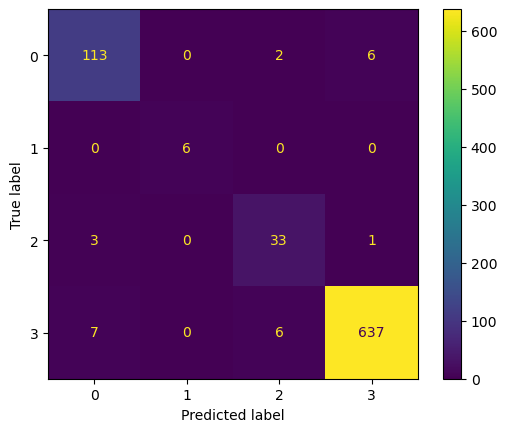

In [17]:
# Shuffle the DataFrame
shuffled_df = shuffle( shuffled_df_numeric[['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'chlorophyll a', 'iron',
'nitrate std', 'radiation 8.1', 'radiation 30', 'sea surface temp grad', 'sea surface temp', 'mhw_category']], random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_df.drop(['mhw_category'], axis=1)
y_imp = shuffled_df['mhw_category']

X_train, X_test, y_train, y_test = tts(
    X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape,
X_test.shape, y_test.shape)

knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)
clf.fit(X_train, y_train)

cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [36]:
shuffled_df.to_csv('13 features - all data points.csv', index = False)

## Dropping all 0 heatwaves

In [24]:
no_0 = shuffled_df_numeric.drop(shuffled_df_numeric[shuffled_df_numeric['mhw_category'] == 3].index)

print(no_0['mhw_category'].value_counts())

# Shuffle the DataFrame
no_0 = shuffle(no_0, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = no_0.drop(['mhw_count', 'mhw_category'], axis=1)
y = no_0[['mhw_category']]
X.shape, y.shape

mhw_category
0    605
2    185
1     31
Name: count, dtype: int64


((821, 68), (821, 1))

## Correlation

In [25]:
class Selective(BaseEstimator, TransformerMixin):
    def __init__(self, selectionmethod):
        self.selectionmethod = selectionmethod
        self.selected_features_ = None
        self.scores_ = None
        
    def fit(self, X, y):
        # Your existing fit implementation
        threshold = self.selectionmethod.threshold
        method = self.selectionmethod.method
        
        # Calculate correlation matrix
        corr_matrix = X.corr(method=method).abs()
        
        # Upper triangle of correlation matrix
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Find features with correlation < threshold
        self.selected_features_ = [column for column in upper.columns 
                                if any(upper[column] < threshold)]
        
        # If all features are correlated, keep at least one
        if not self.selected_features_:
            self.selected_features_ = [corr_matrix.columns[0]]
            
        # Store correlation scores
        self.scores_ = {col: corr_matrix[col].mean() for col in corr_matrix.columns}
        return self
    
    def transform(self, X):
        return X[self.selected_features_]
    
    def get_absolute_scores(self):
        return self.scores_
    
    def get_params(self, deep=True):
        return {"selectionmethod": self.selectionmethod}
    
    def set_params(self, **params):
        if 'selectionmethod__threshold' in params:
            self.selectionmethod.threshold = params['selectionmethod__threshold']
        if 'selectionmethod__method' in params:
            self.selectionmethod.method = params['selectionmethod__method']
        return self

class SelectionMethod:
    class Correlation:
        def __init__(self, threshold=0.5, method="pearson"):
            self.threshold = threshold
            self.method = method

In [26]:
# Create pipeline
pipeline = Pipeline([
    ('selective', Selective(SelectionMethod.Correlation())),
    ('scaler', StandardScaler()),
    ('classifier', KNN())
])

# Parameter grid
param_grid = {
    'selective__selectionmethod__threshold': np.linspace(0, 1, 20),
    'selective__selectionmethod__method': ['pearson', 'spearman']
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search.fit(X, y.values.ravel())

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'selective__selectionmethod__method': 'pearson', 'selective__selectionmethod__threshold': 0.9473684210526315}
Best score: 0.9050110864745011


## Variance

In [27]:
class Selective(BaseEstimator, TransformerMixin):
    def __init__(self, selectionmethod=None):
        self.selectionmethod = selectionmethod
        self.selected_features_ = None
        self.scores_ = None
        
    def fit(self, X, y=None):
        # Sørg for at arbejde med numeriske kolonner
        X_num = X.select_dtypes(include=[np.number])
        
        # Varians pr. feature
        variances = X_num.var()
        
        threshold = self.selectionmethod.threshold
        self.selected_features_ = variances[variances > threshold].index.tolist()
        
        # Hvis ingen features opfylder kravet, behold én
        if not self.selected_features_:
            self.selected_features_ = [variances.idxmax()]
        
        self.scores_ = variances.to_dict()
        return self
    
    def transform(self, X):
        return X[self.selected_features_]
    
    def get_absolute_scores(self):
        return self.scores_

class SelectionMethod:
    class Variance(BaseEstimator):
        def __init__(self, threshold=0.0):
            self.threshold = threshold

In [28]:
# Create pipeline
pipeline_var = Pipeline([
    ('selective', Selective(SelectionMethod.Variance())),
    ('scaler', StandardScaler()),
    ('classifier', KNN())
])

# Parameter grid
param_grid_var = {
    'selective__selectionmethod__threshold': np.linspace(0, 10000, 20)
}

# Setup GridSearchCV
grid_search_var = GridSearchCV(
    estimator=pipeline_var,
    param_grid=param_grid_var,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search_var.fit(X, y.values.ravel())

print("Best parameters:", grid_search_var.best_params_)
print("Best score:", grid_search_var.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'selective__selectionmethod__threshold': 4210.526315789473}
Best score: 0.9159645232815965


## Mutual information

In [29]:
# calculate mutual information
scores = MIC(X, y, random_state = 24)

X_new = SelectKBest(MIC, k=12).fit(X, y)

print('scores:', scores)
print(X_new.get_feature_names_out())

# Alle scores
all_scores = X_new.scores_

#Hent index for de 5 bedste features
top5_indices = X_new.get_support(indices=True)

# Hent de 5 score værdier
top5_scores = all_scores[top5_indices]

# (Valgfrit) Hent feature-navne hvis X er DataFrame
top5_feature_names = X.columns[top5_indices]

# Print
for name, score in zip(top5_feature_names, top5_scores):
    print(f"{name}: {score:.4f}")

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


scores: [0.57469061 0.56254689 0.57744478 0.56762345 0.57392257 0.20491772
 0.49546696 0.50025836 0.56812822 0.06624196 0.07514321 0.48531393
 0.43717598 0.25361559 0.23708986 0.2374955  0.26512976 0.29377707
 0.26183674 0.22687947 0.23521357 0.25023183 0.26353784 0.58674286
 0.01321574 0.03969099 0.05140186 0.50741695 0.49402358 0.5643812
 0.56087613 0.54345393 0.26918898 0.27703068 0.23508623 0.27380797
 0.26933012 0.41383593 0.43117221 0.30534624 0.05352986 0.00625943
 0.0216895  0.03130444 0.         0.26946586 0.26808829 0.2461766
 0.25020874 0.27204564 0.09183167 0.08371738 0.07043637 0.16005541
 0.17164081 0.1783303  0.19148196 0.13300014 0.17698747 0.51771086
 0.43101771 0.01304454 0.47628556 0.49016549 0.50028785 0.56604329
 0.49901459 0.09385385]
['ammonium' 'ammonium std' 'nitrite' 'nitrite std' 'nitrate' 'iron'
 'nitrate std' 'okubo-weiss' 'radiation 8.1' 'radiation 8.2'
 'radiation 30' 'sea surface temp']
ammonium: 0.5792
ammonium std: 0.5599
nitrite: 0.5723
nitrite std: 0

In [33]:
knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)

class MutualInfoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.1):
        self.threshold = threshold
        self.selected_features_ = None
        
    def fit(self, X, y):
        mi_scores = MIC(X, y, random_state = 42)
        self.selected_features_ = np.where(mi_scores > self.threshold)[0]
        return self
    
    def transform(self, X):
        return X.iloc[:, self.selected_features_]

# Create pipeline
pipe = Pipeline([
    ('selector', MutualInfoSelector()),
    ('clf', clf)  # Your classifier
])
y = y.ravel()
# Grid search parameters
param_grid = {
    'selector__threshold': np.linspace(0, 0.6, 20)
}

grid_search = GridSearchCV(pipe, param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X, y)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# After fitting

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
6 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_esti

Best parameters: {'selector__threshold': 0.5052631578947369}
Best score: 0.9695787139689578


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.258131,0.012296,0.027838,0.006787,0.000000,{'selector__threshold': 0.0},0.890909,0.920732,0.932927,0.884146,0.902439,0.906231,0.018220,13
1,0.263339,0.015075,0.019709,0.003514,0.031579,{'selector__threshold': 0.031578947368421054},0.884848,0.914634,0.920732,0.878049,0.902439,0.900140,0.016500,18
2,0.274223,0.012147,0.025535,0.006323,0.063158,{'selector__threshold': 0.06315789473684211},0.896970,0.908537,0.932927,0.871951,0.902439,0.902565,0.019627,17
3,0.262021,0.006049,0.022455,0.008814,0.094737,{'selector__threshold': 0.09473684210526316},0.896970,0.908537,0.932927,0.884146,0.902439,0.905004,0.016114,15
4,0.258163,0.013999,0.027589,0.007592,0.126316,{'selector__threshold': 0.12631578947368421},0.903030,0.908537,0.932927,0.884146,0.902439,0.906216,0.015687,14
5,0.259038,0.017822,0.018185,0.008238,0.157895,{'selector__threshold': 0.15789473684210525},0.903030,0.902439,0.926829,0.890244,0.902439,0.904996,0.011927,16
6,0.268438,0.011093,0.023278,0.003897,0.189474,{'selector__threshold': 0.18947368421052632},0.909091,0.890244,0.932927,0.890244,0.926829,0.909867,0.017834,12
7,0.264541,0.018522,0.024037,0.006435,0.221053,{'selector__threshold': 0.2210526315789474},0.921212,0.890244,0.926829,0.914634,0.914634,0.913511,0.012495,11
8,0.257417,0.013959,0.022396,0.007685,0.252632,{'selector__threshold': 0.25263157894736843},0.903030,0.902439,0.957317,0.951220,0.939024,0.930606,0.023508,10
9,0.255310,0.011548,0.020363,0.006701,0.284211,{'selector__threshold': 0.28421052631578947},0.927273,0.926829,0.975610,0.957317,0.939024,0.945211,0.018807,9


In [34]:
# 1. First select features
mi_score_selected_index = np.where(scores >0.5)[0]
X_2 = X.iloc[:,mi_score_selected_index]
X_2

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron std,iron,nitrate std,okubo-weiss,radiation 8.1,radiation 8.2,radiation 30,sea surface chlorophyll a,sea surface temp grad,sea surface temp
796,0.011776,0.001189,0.006971,0.002028,0.003837,0.000080,0.000995,0.000916,-0.065955,36.561363,35.642069,36.620970,0.062506,0.442490,27.165588
2018,0.042527,0.009718,0.645360,0.275633,6.029549,0.000001,0.000005,2.465427,0.032297,50.950092,48.702957,47.305930,0.215110,2.334500,23.963287
817,0.011299,0.001129,0.008025,0.003129,0.004059,0.000103,0.000977,0.001711,0.125682,36.615753,35.151533,35.655544,0.065133,0.890760,27.668205
3690,0.001088,0.000728,0.006602,0.006331,6.861202,0.000048,0.001105,2.833806,-0.176985,19.563871,22.488691,17.078548,0.539852,1.497619,2.471750
3253,0.022560,0.007138,0.052923,0.046198,0.325422,0.000243,0.000995,0.515146,-0.093316,29.742392,26.461164,28.952892,0.307433,0.631270,13.967590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44,0.017880,0.002648,0.030634,0.004815,0.073991,0.000007,0.001383,0.065849,-0.176985,44.252100,42.836414,40.733418,2.707993,6.349700,21.384417
810,0.011299,0.001129,0.008025,0.003129,0.004059,0.000103,0.000977,0.001711,0.125682,36.615753,35.944500,35.655544,0.051397,1.065500,27.796727
1143,0.011293,0.002375,0.018235,0.002509,0.036490,0.000066,0.001262,0.023011,0.006396,49.718075,50.455746,55.147900,0.055295,0.325000,24.982502
886,0.021539,0.011060,0.078181,0.042540,2.248219,0.000078,0.000913,1.142004,-0.176985,38.738630,37.684546,38.497997,0.141889,0.359980,27.041458


mhw_category
0    605
2    185
1     31
Name: count, dtype: int64
(656, 15) (656,) (165, 15) (165,)
cross validation scores: [0.96969697 0.95731707 0.95731707 0.96341463 0.98780488]
0.9671 accuracy with a standard deviation of 0.0113
Accuracy: 96.97%
[[120   1   1]
 [  0   6   0]
 [  3   0  34]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       122
           1       0.86      1.00      0.92         6
           2       0.97      0.92      0.94        37

    accuracy                           0.97       165
   macro avg       0.93      0.97      0.95       165
weighted avg       0.97      0.97      0.97       165



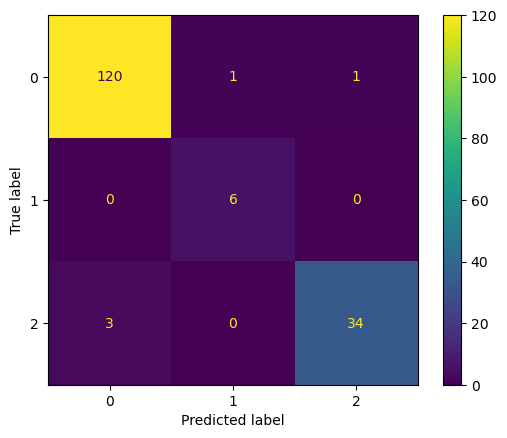

In [45]:
# Shuffle the DataFrame
small = shuffle( no_0[['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'sea surface chlorophyll a', 'iron', 'iron std',
'nitrate std', 'radiation 8.1', 'radiation 30', 'radiation 8.2', 
                       'sea surface temp grad', 'sea surface temp', 'okubo-weiss', 'mhw_category']], random_state=42)

print(small['mhw_category'].value_counts())

# Separate features (X) and labels (y) after shuffling
X_imp = small.drop(['mhw_category'], axis=1)
y_imp = small['mhw_category']

X_train, X_test, y_train, y_test = tts(
    X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape,
X_test.shape, y_test.shape)

knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)
clf.fit(X_train, y_train)

cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [48]:
shuffled_df.to_csv('15 variables - 0 heatwaves removed.csv', index = False)

In [47]:
df_un = pd.read_csv('TARA_mhws_3.csv')
df_un.shape

(4066, 94)

In [53]:
dropped = df_un.drop(df_un[df_un['mhw_category'] == 'none'].index)

print(dropped['mhw_category'].value_counts())

# Shuffle the DataFrame
dropped = shuffle(dropped, random_state=42)

mhw_category
Moderate    605
Strong      185
Severe       31
Name: count, dtype: int64


In [54]:
df_unin = dropped[['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'nitrate std', 'iron', 'iron std', 'okubo-weiss',
                 'sea surface chlorophyll a',
 'radiation 8.1', 'radiation 8.2', 'radiation 30', 'sea surface temp grad', 'sea surface temp', 'mhw_category']]
df_unin

,ammonium,ammonium std,nitrite,nitrite std,nitrate,nitrate std,iron,iron std,okubo-weiss,sea surface chlorophyll a,radiation 8.1,radiation 8.2,radiation 30,sea surface temp grad,sea surface temp,mhw_category
3004,0.013131,0.002737,0.114781,0.067715,2.422716,2.497678,0.000895,8.146000e-05,-0.044917,0.360407,16.350664,15.861004,19.370090,2.69650,14.378073,Severe
605,0.021486,0.001870,0.003789,0.000826,0.004909,0.002530,0.001388,3.000000e-09,0.043242,0.296852,55.157024,53.085646,52.909405,0.29196,28.712336,Strong
79,0.015064,0.003309,0.027280,0.007183,0.005332,0.003286,0.001388,2.000000e-09,0.575455,0.094840,28.279560,30.273886,37.798237,0.95289,23.640099,Moderate
599,0.021486,0.001870,0.003789,0.000826,0.004909,0.002530,0.001388,3.000000e-09,0.043242,0.260143,55.157024,53.147472,52.909405,0.29196,28.702478,Strong
781,0.011776,0.001189,0.006971,0.002028,0.003837,0.000916,0.000995,8.039400e-05,-0.065955,0.062506,36.561363,35.642069,36.620970,0.37852,27.165588,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0.015064,0.003309,0.027280,0.007183,0.005332,0.003286,0.001388,2.000000e-09,0.575455,0.093876,28.279560,30.590260,37.798237,0.95289,23.640099,Moderate
121,0.012591,0.001338,0.041707,0.028490,0.016741,0.015524,0.001388,2.000000e-09,0.063913,0.129373,32.225647,32.101795,37.693394,0.92875,23.148416,Moderate
773,0.011668,0.001849,0.004894,0.001387,0.006942,0.003370,0.001104,7.880900e-05,0.211970,0.458568,39.955235,38.923872,43.630440,0.61512,27.877569,Moderate
1119,0.012845,0.000930,0.029691,0.004530,0.012457,0.004551,0.001244,7.793400e-05,0.005060,0.074474,46.834354,48.058519,45.797413,0.25556,23.611718,Moderate


In [55]:
df_unin.to_csv('15 features - no imp.csv', index = False)